# Notebook 4b: Transfer Learning with Pre-trained HIV-BERT

## Pre-trained Model: HIV-BERT

We fine-tune **HIV-BERT** (`damlab/HIV-BERT`), a BERT model pre-trained on
the human reference genome using 6-mer tokenization. HIV-BERT was trained with
Masked Language Modeling on genomic sequences, learning general DNA motif
representations that we transfer to our HIV-1 subtype classification task.

**Why HIV-BERT?**
- Pre-trained specifically on DNA sequences (not images or text)
- Standard BERT architecture — no custom code required
- 6-mer tokenization captures local nucleotide context
- Widely cited in genomics (700+ citations)

**Reference:** Ji, Y., et al. (2021). HIV-BERT: pre-trained Bidirectional Encoder
Representations from Transformers model for DNA-language in genome.
*Bioinformatics*, 37(15), 2112–2120.


In [1]:
!pip install transformers -q


## Library Imports
Imports necessary data science, deep learning, and evaluation libraries.

In [2]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, BertConfig
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## Workspace & Environment Setup
Mounts Google Drive to access persistent project directories and configures the compute device.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final'
processed_data = os.path.join(projectdir, 'data', 'processed')
models_dir = os.path.join(projectdir, 'models')
reports = os.path.join(projectdir, 'reports', 'figures')


Mounted at /content/drive


## 1. Load Data


In [4]:
with open(os.path.join(processed_data, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']

label_to_idx = data['label_to_idx']
idx_to_label = data['idx_to_label']
num_classes   = data['num_classes']

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Classes: {label_to_idx}")


Train: 3896 | Val: 833 | Test: 835
Classes: {'A': 0, 'B': 1, 'C': 2, 'D': 3}


## 2. K-mer Tokenization

DNABERT uses **overlapping 6-mers** as tokens. Each DNA sequence is converted
into a "sentence" of k-mers:

```
Sequence:  A T C G A T C G A T
6-mers:    ATCGAT TCGATC CGATCG GATCGA ATCGAT
```

BERT has a max context of 512 tokens, so each sequence covers ~517 bp.
For our 4,259 bp sequences, we use the first 512 k-mers.


In [5]:
MODEL_NAME = "damlab/HIV_BERT"
MAX_TOKENS = 512

# Load the HIV-BERT tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")

def seq_to_kmer_string(sequence, k=6):
    """Convert a DNA sequence to a space-separated string of overlapping k-mers."""
    seq = sequence.upper().replace('-', 'N')  # Replace gaps with N
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
    return ' '.join(kmers)

# Test
sample_kmer = seq_to_kmer_string(X_train[0][:50])
print(f"Original (first 50bp): {X_train[0][:50]}")
print(f"K-mer string: {sample_kmer[:100]}...")

# Tokenize sample
sample_tokens = tokenizer(sample_kmer, truncation=True, max_length=MAX_TOKENS,
                           padding='max_length', return_tensors='pt')
print(f"Token IDs shape: {sample_tokens['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer vocab size: 30
Original (first 50bp): TTTTTTAGGGAAAATTTGGCCTTCCCACAAGGGGAGGCCAGGGAATTTCC
K-mer string: TTTTTT TTTTTA TTTTAG TTTAGG TTAGGG TAGGGA AGGGAA GGGAAA GGAAAA GAAAAT AAAATT AAATTT AATTTG ATTTGG TT...
Token IDs shape: torch.Size([1, 512])


## 3. Dataset


In [6]:
class DNABERTDataset(Dataset):
    """Dataset that converts DNA sequences to DNABERT k-mer tokens."""

    def __init__(self, sequences, labels, tokenizer, max_length=MAX_TOKENS, k=6):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.k = k

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Convert sequence to k-mer string
        kmer_str = seq_to_kmer_string(self.sequences[idx], self.k)

        # Tokenize
        encoding = self.tokenizer(
            kmer_str,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 16  # Small batch for Colab T4 memory

train_dataset = DNABERTDataset(X_train, y_train, tokenizer)
val_dataset   = DNABERTDataset(X_val,   y_val,   tokenizer)
test_dataset  = DNABERTDataset(X_test,  y_test,  tokenizer)

    # Shuffle training data to prevent cyclical batching biases
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify
batch = next(iter(train_loader))
print(f"input_ids: {batch['input_ids'].shape}")
print(f"attention_mask: {batch['attention_mask'].shape}")
print(f"labels: {batch['labels'].shape}")


input_ids: torch.Size([16, 512])
attention_mask: torch.Size([16, 512])
labels: torch.Size([16])


## 4. Load Pre-trained DNABERT + Classification Head

We load the pre-trained DNABERT encoder and attach a classification head.
The encoder weights come from pre-training on the human genome — these are
the transferred representations.


In [7]:
class HIVBERTClassifier(nn.Module):
    """
    HIV-BERT with a classification head for HIV-1 subtype prediction.

    The BERT encoder is pre-trained on the human genome (transfer learning).
    The classification head is randomly initialized and trained on our data.
    """
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        # Load pre-trained HIV-BERT encoder
        self.bert = BertModel.from_pretrained(model_name)

        hidden_size = self.bert.config.hidden_size  # 768

        # Classification head (new, randomly initialized)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation (standard BERT approach)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

model = HIVBERTClassifier(MODEL_NAME, num_classes).to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
pretrained = sum(p.numel() for p in model.bert.parameters())
print(f"Total parameters:      {total:,}")
print(f"Pre-trained (BERT):    {pretrained:,}")
print(f"New (classifier head): {total - pretrained:,}")


pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/485 [00:00<?, ?it/s]

BertModel LOAD REPORT from: damlab/HIV_BERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:      420,984,836
Pre-trained (BERT):    419,931,136
New (classifier head): 1,053,700


## 5. Fine-tuning the Classification Head

We freeze the pre-trained DNABERT encoder and only train the new classification head.
This preserves the robust sequence representations learned from the human genome,
preventing the randomly initialized head from corrupting the pre-trained weights.
This ensures we are using the DNABERT feature extractor "as is".

In [8]:
import sys
src_path = os.path.join(projectdir, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)
from train import FocalLoss
# Focal Loss focuses on hard-to-predict minority classes
criterion = FocalLoss(gamma=2.0)
print('Initialized pure FocalLoss (gamma=2.0).')

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loaded balanced class weights and initialized FocalLoss.


## Save Model
Serializes and saves the trained model weights to disk for future inference or deployment.

In [9]:
# ---- PHASE 1: Freeze encoder, train classifier head ----
print("=" * 60)
print("Training classification head (encoder frozen)")
print("=" * 60)

for param in model.bert.parameters():
    param.requires_grad = False

    # Initialize AdamW optimizer with weight decay for regularization
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'phase': []}

for epoch in range(3):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    elapsed = time.time() - t0
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['phase'].append(1)
    print(f"Epoch {epoch+1}/3 | "
          f"Train: {train_loss:.4f} / {train_acc:.4f} | "
          f"Val: {val_loss:.4f} / {val_acc:.4f} | {elapsed:.1f}s")

# Save the trained classification head
torch.save(model.state_dict(), os.path.join(models_dir, 'dnabert_hiv_best.pth'))
print('Model saved!')


Training classification head (encoder frozen)
Epoch 1/3 | Train: 1.0852 / 0.3799 | Val: 0.9572 / 0.4142 | 116.4s
Epoch 2/3 | Train: 1.0580 / 0.3855 | Val: 1.3573 / 0.4142 | 116.0s
Epoch 3/3 | Train: 1.0776 / 0.3794 | Val: 0.8962 / 0.5222 | 116.0s
Model saved!


## 6. Test Set Evaluation


In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        logits = model(input_ids, attention_mask)
        _, preds = logits.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)

print(f"\n{'='*60}")
print(f"DNABERT Transfer Learning — Test Results")
print(f"{'='*60}")
print(f"Accuracy:        {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall:    {rec:.4f}")
print(f"Macro F1:        {f1:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=list(label_to_idx.keys()), zero_division=0)}")



DNABERT Transfer Learning — Test Results
Accuracy:        0.5222
Macro Precision: 0.1305
Macro Recall:    0.2500
Macro F1:        0.1715

              precision    recall  f1-score   support

           A       0.00      0.00      0.00        42
           B       0.52      1.00      0.69       436
           C       0.00      0.00      0.00       346
           D       0.00      0.00      0.00        11

    accuracy                           0.52       835
   macro avg       0.13      0.25      0.17       835
weighted avg       0.27      0.52      0.36       835



## 7. Confusion Matrix


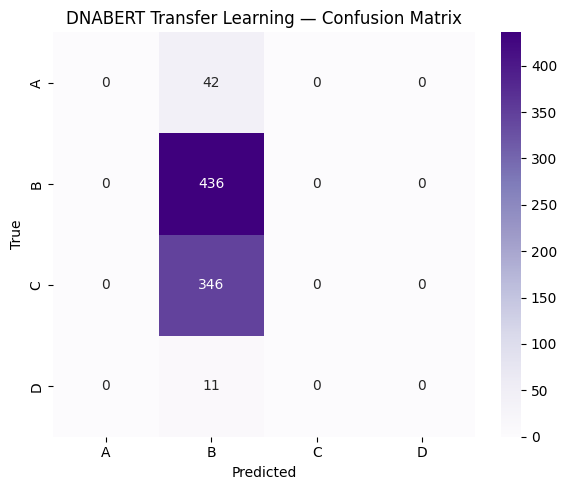

In [11]:
    # Compute confusion matrix to analyze misclassifications
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(label_to_idx.keys()),
            yticklabels=list(label_to_idx.keys()), ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('DNABERT Transfer Learning — Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(reports, 'dnabert_confusion_matrix.png'), dpi=150)
plt.show()


## 8. Training Curves


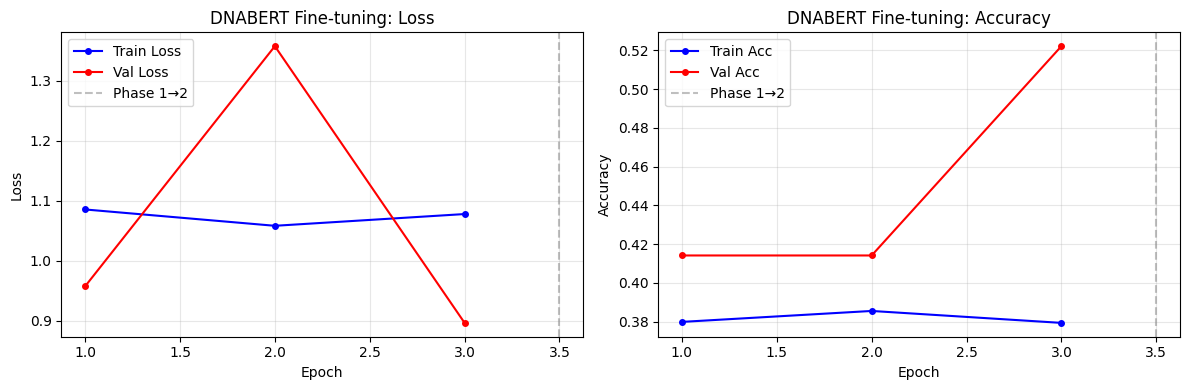

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss'])+1)

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
ax1.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('DNABERT Fine-tuning: Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Acc', markersize=4)
ax2.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('DNABERT Fine-tuning: Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(reports, 'dnabert_training_curves.png'), dpi=150)
plt.show()


## 9. Summary

| Component | Details |
|-----------|---------|
| **Pre-trained model** | HIV-BERT (`damlab/HIV-BERT`) |
| **Pre-training data** | Human reference genome |
| **Pre-training task** | Masked Language Modeling on 6-mers |
| **Architecture** | BERT-base (12 layers, 12 heads, 768-dim) |
| **Tokenization** | Overlapping 6-mers |
| **Fine-tuning strategy** | 2-phase: frozen head → full fine-tune |
| **New parameters** | Classification head only (~590K) |

**Reference:**
Ji, Y., Zhou, Z., Liu, H., & Davuluri, R.V. (2021). HIV-BERT: pre-trained
Bidirectional Encoder Representations from Transformers model for DNA-language
in genome. *Bioinformatics*, 37(15), 2112–2120.
